# Extension stage: FSO using a LEO satellite

**A satellite-to-ground optical link added to the existing QKD–FSO project.**

The existing terrestrial FSO, BB84, Eve, LDPC reconciliation and Toeplitz privacy-amplification stages remain in their original files. This companion stage studies a moving **low Earth orbit (LEO) satellite sending optical pulses down to one ground station**. It connects orbit geometry to loss, detection probability, QBER and a pass-integrated key-rate benchmark.

An experimental satellite-to-ground QKD demonstration motivates the link direction; the numbers below are illustrative project inputs, not a reconstruction of that mission. [Liao et al., *Satellite-to-ground quantum key distribution*, Nature (2017)](https://www.nature.com/articles/nature23655).

**What this notebook computes:** an ideal circular overhead pass, a clear-sky optical budget, and a model-known infinite-decoy asymptotic benchmark. **Baseline Eve interception is zero.** A finite, changing pass needs a separate finite-key analysis before any output can be called a certified secret-key length. [Sidhu et al., *Finite key effects in satellite quantum key distribution*](https://arxiv.org/abs/2012.07829).

Run all cells from top to bottom with `leo_model.py` beside this notebook. The executed HTML version can be opened directly in a browser.

## 1. How this extends the project

| Project stage | Role in this extension |
|---|---|
| Existing terrestrial FSO channel | Preserved as the original baseline |
| **New LEO pass and optical downlink** | Supplies elevation, range, channel efficiency and QBER over time |
| Existing BB84 and Eve illustration | Reusable teaching stage; the link-rate curves here use no Eve attack |
| Existing LDPC reconciliation | Receives a representative satellite-link QBER in the Octave extension |
| Existing Toeplitz hashing | Remains the project's privacy-amplification demonstration |

The optical path is **satellite transmitter → mostly vacuum → a short atmospheric segment → ground telescope → detector**. Applying a terrestrial dB/km coefficient to the full satellite range would incorrectly fill space with atmosphere.

The companion Octave entry point `../START_QKD_LEO.m` connects this new channel model to the existing postprocessing functions. This notebook focuses on the independent numerical link model. A successful toy reconciliation/hash demonstration does not establish the finite-key security of the pass.

In [1]:
from dataclasses import asdict, replace
from pathlib import Path
import json
import sys

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

# Find the model when launched from this stage, the project root, or a subfolder.
search_roots = (Path.cwd(), *Path.cwd().parents)
extension_dir = next((candidate for root in search_roots
                      for candidate in (root, root / "2-Ground Station and Satellite")
                      if (candidate / "leo_model.py").is_file()), None)
if extension_dir is None:
    raise FileNotFoundError("Run the notebook from its stage folder or project root.")
sys.path.insert(0, str(extension_dir.resolve()))
from leo_model import LEOParameters, binary_entropy, link_at_elevation, simulate_pass

p = LEOParameters()
p.validate()
figure_dir = extension_dir / "python_figures"
figure_dir.mkdir(exist_ok=True)
plt.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 180,
    "font.size": 10, "axes.titlesize": 12,
    "axes.labelcolor": "#243449", "text.color": "#14283f",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.18,
    "axes.prop_cycle": plt.cycler(color=["#007f86", "#253e69", "#d68727", "#9473a5"]),
})

def table(headers, rows):
    display(Markdown("| " + " | ".join(headers) + " |\n| " + " | ".join(["---"] * len(headers))
                     + " |\n" + "\n".join("| " + " | ".join(str(x) for x in row) + " |" for row in rows)))

def save_figure(fig, name):
    fig.savefig(figure_dir / (name + ".png"), bbox_inches="tight", facecolor="white")
    plt.show()

## 2. Explicit project assumptions

The geometry uses a spherical, nonrotating Earth and a circular orbit passing directly overhead. The receiver is at sea level. The atmosphere is an **effective uniform 20 km loss shell**; it is a convenient attenuation model, not a boundary beyond which air vanishes. The Gaussian beam radius follows a supplied divergence; wavelength is therefore implicit in that input.

All hardware and atmospheric values in the next table are **illustrative defaults chosen for this extension**. They are not claimed mission measurements. The signal fraction reserves 20% of all emitted pulses for other choices; this notebook does **not** simulate decoy selection or infer bounds from decoy observations.

In [2]:
table(["Parameter", "Default", "Meaning"], [
    ["Earth radius", f"{p.earth_radius_km:g} km", "Spherical Earth"],
    ["Satellite altitude", f"{p.altitude_km:g} km", "Circular overhead orbit"],
    ["Earth gravitational parameter", f"{p.gravitational_parameter_km3_s2:.4f} km³/s²", "Sets angular speed"],
    ["Elevation cutoff / samples", f"{p.minimum_elevation_deg:g}° / {p.sample_count}", "Visible pass interval"],
    ["Effective atmosphere height / zenith loss", f"{p.atmosphere_height_km:g} km / {p.zenith_atmosphere_loss_db:g} dB", "Only the in-atmosphere path is attenuated"],
    ["Initial beam radius / divergence", f"{p.beam_waist_m:g} m / {p.divergence_rad * 1e6:g} µrad", "1/e² intensity radius and half-angle"],
    ["Receiver radius (diameter)", f"{p.receiver_radius_m:g} m ({2*p.receiver_radius_m:g} m)", "Centered circular collection aperture"],
    ["Pointing loss", f"{p.pointing_loss_db:g} dB", "Constant allowance, no jitter simulation"],
    ["Optics / detector efficiency", f"{p.optical_efficiency:g} / {p.detector_efficiency:g}", "Multiplicative detection factors"],
    ["Mean photons per signal pulse", f"{p.mean_photons:g}", "Weak coherent pulse source"],
    ["Background yield per gate", f"{p.background_yield:g}", "Total background-click probability, not counts/s"],
    ["Optical error probability", f"{100*p.optical_error_probability:g}%", "Misalignment baseline"],
    ["Error-correction inefficiency", f"{p.error_correction_efficiency:g}", "Shannon-limit multiplier"],
    ["Total pulse rate / signal fraction", f"{p.pulse_rate_hz / 1e6:g} MHz / {p.signal_duty:g}", "Signal duty is applied once"],
    ["Basis-sifting fraction", f"{p.basis_sift:g}", "Unbiased BB84"],
])

| Parameter | Default | Meaning |
| --- | --- | --- |
| Earth radius | 6371 km | Spherical Earth |
| Satellite altitude | 500 km | Circular overhead orbit |
| Earth gravitational parameter | 398600.4418 km³/s² | Sets angular speed |
| Elevation cutoff / samples | 10° / 401 | Visible pass interval |
| Effective atmosphere height / zenith loss | 20 km / 2 dB | Only the in-atmosphere path is attenuated |
| Initial beam radius / divergence | 0.05 m / 10 µrad | 1/e² intensity radius and half-angle |
| Receiver radius (diameter) | 0.5 m (1 m) | Centered circular collection aperture |
| Pointing loss | 1 dB | Constant allowance, no jitter simulation |
| Optics / detector efficiency | 0.7 / 0.5 | Multiplicative detection factors |
| Mean photons per signal pulse | 0.5 | Weak coherent pulse source |
| Background yield per gate | 2e-06 | Total background-click probability, not counts/s |
| Optical error probability | 1.5% | Misalignment baseline |
| Error-correction inefficiency | 1.16 | Shannon-limit multiplier |
| Total pulse rate / signal fraction | 100 MHz / 0.8 | Signal duty is applied once |
| Basis-sifting fraction | 0.5 | Unbiased BB84 |

## 3. Orbit geometry and contact time

Let $R_E$ be Earth radius, $h$ altitude, $r=R_E+h$, $e_{\min}$ the elevation cutoff and $\mu_E$ Earth's gravitational parameter. For an ideal overhead pass,

$$\theta_{\max}=\cos^{-1}\!\left(\frac{R_E}{r}\cos e_{\min}\right)-e_{\min},\qquad
\omega=\sqrt{\frac{\mu_E}{r^3}},\qquad
-\frac{\theta_{\max}}{\omega}\le t\le\frac{\theta_{\max}}{\omega}.$$

The central angle is $\theta=\omega t$. Range and elevation follow directly from the Earth–station–satellite triangle:

$$L(t)=\sqrt{h^2+2R_Er(1-\cos\theta)},\qquad
e(t)=\operatorname{atan2}(r\cos\theta-R_E,\ r\sin|\theta|).$$

The closest approach is $t=0$, where $L=h$ and $e=90^\circ$. The plotted interval begins and ends at the selected elevation cutoff. Actual orbital tracks require Earth rotation, station coordinates and orbit data; those are outside this ideal geometry.

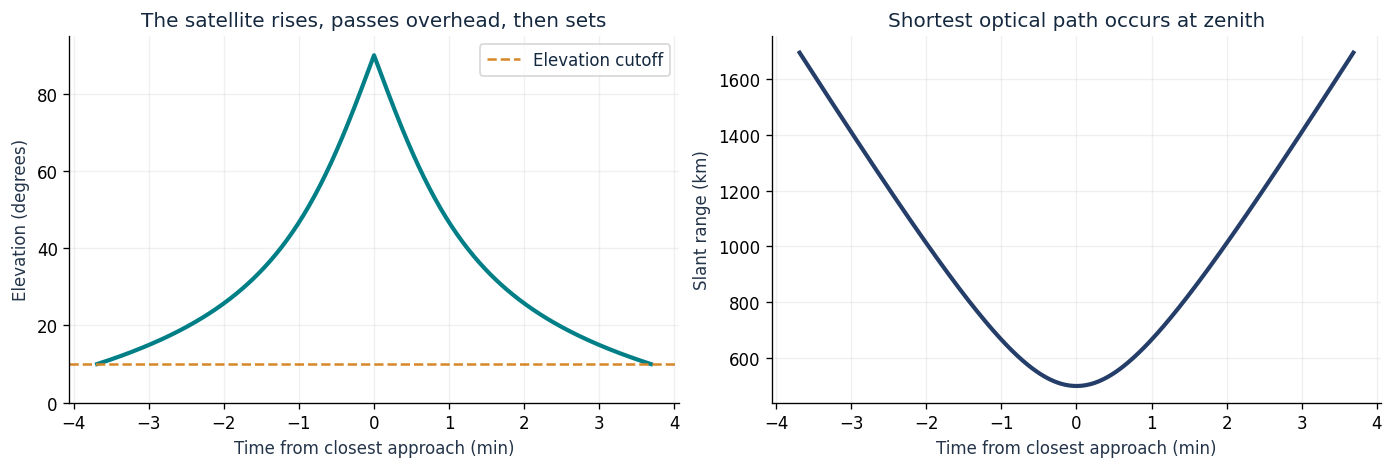

Usable ideal pass: 442.64 s (7.38 min).


In [3]:
baseline = simulate_pass(p)
t_min = baseline["time_s"] / 60
fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.8), layout="constrained")
axes[0].plot(t_min, baseline["elevation_deg"], linewidth=2.5)
axes[0].axhline(p.minimum_elevation_deg, color="#d68727", linestyle="--", label="Elevation cutoff")
axes[0].set(xlabel="Time from closest approach (min)", ylabel="Elevation (degrees)",
            title="The satellite rises, passes overhead, then sets", ylim=(0, 95))
axes[0].legend(loc="upper right")
axes[1].plot(t_min, baseline["slant_range_km"], color="#253e69", linewidth=2.5)
axes[1].set(xlabel="Time from closest approach (min)", ylabel="Slant range (km)",
            title="Shortest optical path occurs at zenith")
save_figure(fig, "leo_pass_geometry")
print(f'Usable ideal pass: {baseline["metrics"]["pass_duration_s"]:.2f} s '
      f'({baseline["metrics"]["pass_duration_s"]/60:.2f} min).')

## 4. Separate atmospheric loss from beam spreading

For effective atmosphere height $H$, the spherical-shell segment along the line of sight is

$$s_{\mathrm{atm}}(e)=\sqrt{(R_E+H)^2-R_E^2\cos^2e}-R_E\sin e,$$
$$A_{\mathrm{atm}}(e)=A_z\frac{s_{\mathrm{atm}}(e)}{H}.$$

This is a direct ray/sphere-intersection calculation. At zenith the segment is $H$, even though the satellite is hundreds of kilometres away.

With an effective Gaussian beam and a centered receiver of radius $a$,

$$w(L)=\sqrt{w_0^2+(\vartheta L)^2},\qquad
\eta_g=1-\exp\!\left(-\frac{2a^2}{w(L)^2}\right).$$

Here $w$ is the $1/e^2$ intensity radius and $\vartheta$ is the divergence half-angle. Use metres for $L$ in this formula. The Gaussian collection and finite atmospheric-path approximations are consistent with the class of simplified satellite-link models discussed by [Khatri et al., *Spooky action at a global distance*, npj Quantum Information (2021)](https://www.nature.com/articles/s41534-020-00327-5); the effective shell and all numeric inputs here are project choices.

Finally,

$$\eta=\eta_g\,10^{-A_{\mathrm{atm}}/10}\,10^{-A_{\mathrm{point}}/10}\,\eta_{\mathrm{opt}}\,\eta_{\mathrm{det}},\qquad
A_{\mathrm{total}}=-10\log_{10}\eta.$$

This total includes detector inefficiency. Atmospheric extinction uses only $s_{\mathrm{atm}}$; beam spreading uses the full satellite range.

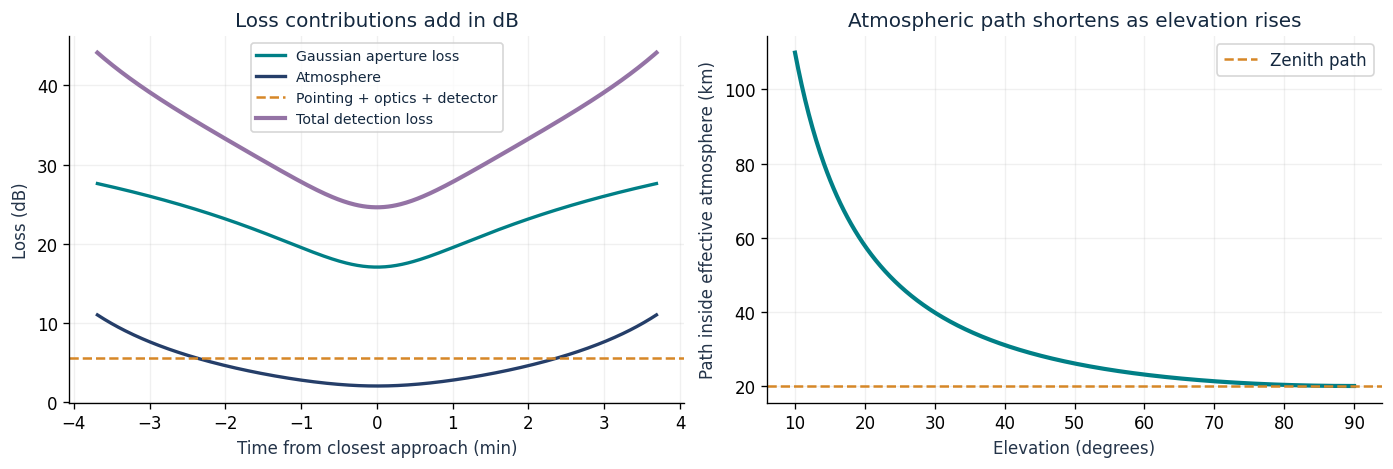

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.8), layout="constrained")
axes[0].plot(t_min, baseline["geometric_loss_db"], label="Gaussian aperture loss", linewidth=2)
axes[0].plot(t_min, baseline["atmosphere_loss_db"], label="Atmosphere", linewidth=2)
fixed_loss = p.pointing_loss_db - 10*np.log10(p.optical_efficiency*p.detector_efficiency)
axes[0].axhline(fixed_loss, color="#d68727", linestyle="--", label="Pointing + optics + detector")
axes[0].plot(t_min, baseline["total_loss_db"], label="Total detection loss", linewidth=2.5, color="#9473a5")
axes[0].set(xlabel="Time from closest approach (min)", ylabel="Loss (dB)", title="Loss contributions add in dB")
axes[0].legend(fontsize=8.5)
axes[1].plot(baseline["elevation_deg"][:201], baseline["atmosphere_path_km"][:201], linewidth=2.5)
axes[1].axhline(p.atmosphere_height_km, color="#d68727", linestyle="--", label="Zenith path")
axes[1].set(xlabel="Elevation (degrees)", ylabel="Path inside effective atmosphere (km)",
            title="Atmospheric path shortens as elevation rises")
axes[1].legend()
save_figure(fig, "leo_loss_budget")

## 5. From received photons to QBER and key-rate benchmarks

For mean signal-pulse photon number $\mu_s$ and total efficiency $\eta$, the probability of at least one signal detection is $S=1-\exp(-\mu_s\eta)$. A background click with probability $Y_0$ fills a gate that has no signal click. With optical error probability $e_d$,

$$Q_{\mu}=S+(1-S)Y_0,\qquad
E_{\mu}=\frac{e_dS+\tfrac12(1-S)Y_0}{Q_{\mu}}.$$

The model uses signal-priority bookkeeping for coincident signal/background events. Empty channels have undefined QBER (`NaN`) and zero key rate. A channel containing only background has QBER $1/2$. Below the elevation cutoff the receiver is treated as unavailable: signal and background gates are closed, gain/rates are zero and QBER is undefined.

For the ideal decoy benchmark, the model supplies the single-photon quantities directly:

$$Y_1=\eta+(1-\eta)Y_0,\quad
e_1=\frac{e_d\eta+\tfrac12(1-\eta)Y_0}{Y_1},\quad
Q_1=\mu_s e^{-\mu_s}Y_1.$$

Let $h_2(x)=-x\log_2x-(1-x)\log_2(1-x)$, with zero at either endpoint. The retained project-style BB84 reference is

$$r_{\mathrm{ref}}=qQ_{\mu}\max\{1-(1+f_{EC})h_2(E_{\mu}),0\}.$$

It is a teaching comparison, not a security bound for untagged weak coherent pulses. The single-photon-aware ideal asymptotic benchmark is

$$r_{\mathrm{decoy}}=q\max\{Q_1[1-h_2(e_1)]-f_{EC}Q_{\mu}h_2(E_{\mu}),0\}.$$

This is the standard asymptotic decoy-state rate form with **model-known** $Y_1,e_1$. Actual decoy experiments estimate suitable bounds from observations, which this notebook does not do. [Ma et al., *Practical Decoy State for Quantum Key Distribution*, Eq. (1)](https://arxiv.org/abs/quant-ph/0503005).

Both $r$ values already include basis sifting $q=1/2$ and have units of bits per **signal pulse**. Apply the total pulse rate $f_p$ and signal fraction $p_s$ once:

$$K(t)=f_p p_s r_{\mathrm{decoy}}(t),\qquad
N_{\mathrm{asym}}=\int K(t)\,dt.$$

$N_{\mathrm{asym}}$ is an integrated ideal asymptotic benchmark in bits; it is not a certified finite-key output or the length of a generated bit string.

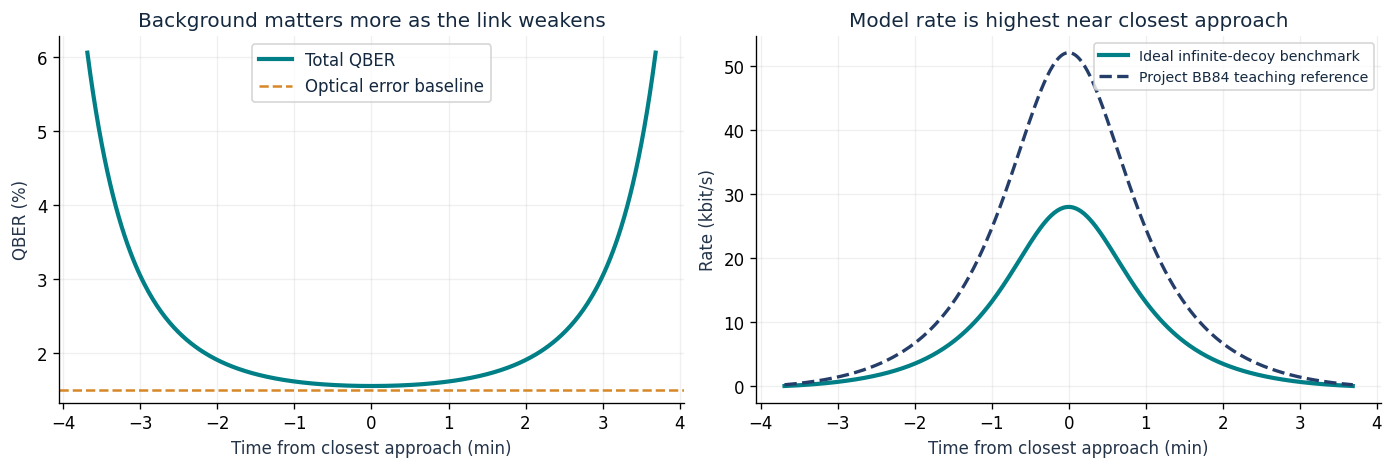

| Pass metric | Result |
| --- | --- |
| Duration above cutoff | 442.636 s |
| Minimum / maximum range | 500.000 / 1694.567 km |
| Peak ideal benchmark rate | 28.022 kbit/s |
| Expected signal-pulse detections (background included) | 19,159,514.7 |
| Expected sifted bits | 9,579,757.4 |
| Integrated ideal asymptotic benchmark | 3,757,445.7 bits |

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.8), layout="constrained")
axes[0].plot(t_min, 100*baseline["qber"], label="Total QBER", linewidth=2.5)
axes[0].axhline(100*p.optical_error_probability, color="#d68727", linestyle="--", label="Optical error baseline")
axes[0].set(xlabel="Time from closest approach (min)", ylabel="QBER (%)",
            title="Background matters more as the link weakens")
axes[0].legend()
axes[1].plot(t_min, baseline["key_rate_bps"]/1000, label="Ideal infinite-decoy benchmark", linewidth=2.5)
reference_bps = baseline["rate_bb84_reference_per_pulse"] * p.pulse_rate_hz * p.signal_duty
axes[1].plot(t_min, reference_bps/1000, linestyle="--", label="Project BB84 teaching reference", linewidth=2)
axes[1].set(xlabel="Time from closest approach (min)", ylabel="Rate (kbit/s)",
            title="Model rate is highest near closest approach")
axes[1].legend(fontsize=8.5)
save_figure(fig, "leo_qber_rates")

m = baseline["metrics"]
table(["Pass metric", "Result"], [
    ["Duration above cutoff", f'{m["pass_duration_s"]:.3f} s'],
    ["Minimum / maximum range", f'{m["minimum_range_km"]:.3f} / {m["maximum_range_km"]:.3f} km'],
    ["Peak ideal benchmark rate", f'{m["peak_key_rate_bps"]/1000:.3f} kbit/s'],
    ["Expected signal-pulse detections (background included)", f'{m["expected_detections"]:,.1f}'],
    ["Expected sifted bits", f'{m["expected_sifted_bits"]:,.1f}'],
    ["Integrated ideal asymptotic benchmark", f'{m["asymptotic_key_bits"]:,.1f} bits'],
])

## 6. Worked example: a satellite at 60° elevation

At one instant, range is found from the orbit/sightline intersection:

$$L(e)=\sqrt{(R_E+h)^2-R_E^2\cos^2e}-R_E\sin e.$$

The next table evaluates that geometry and each successive part of the optical/QKD model. This is also a useful representative channel condition for the existing Octave BB84–LDPC–Toeplitz illustration. A single 60° example does not stand in for the varying channel over the entire pass.

In [6]:
example = link_at_elevation(60.0, p)
table(["Quantity at 60°", "Computed value"], [
    ["Slant range", f'{example["slant_range_km"]:.6f} km'],
    ["Effective atmospheric path", f'{example["atmosphere_path_km"]:.6f} km'],
    ["Beam radius at receiver", f'{example["beam_radius_m"]:.6f} m'],
    ["Gaussian collection efficiency", f'{example["geometric_efficiency"]:.8f}'],
    ["Atmospheric loss", f'{example["atmosphere_loss_db"]:.6f} dB'],
    ["Total loss, including detector", f'{example["total_loss_db"]:.6f} dB'],
    ["End-to-end detection efficiency", f'{example["eta"]:.8f}'],
    ["Gain per signal pulse", f'{example["gain"]:.8f}'],
    ["QBER", f'{100*example["qber"]:.6f}%'],
    ["Ideal decoy benchmark per signal pulse", f'{example["rate_decoy_per_pulse"]:.8f} bits'],
    ["Ideal decoy benchmark rate", f'{example["key_rate_bps"]:.3f} bit/s'],
])
display(Markdown(
    f'**Unit check:** $K = ({p.pulse_rate_hz:g} \;\mathrm{{pulses/s}})'
    f'({p.signal_duty:g})({example["rate_decoy_per_pulse"]:.8f} \;\mathrm{{bits/signal\ pulse}})'
    f' = {example["key_rate_bps"]:.3f} \;\mathrm{{bits/s}}$.'))

| Quantity at 60° | Computed value |
| --- | --- |
| Slant range | 570.510000 km |
| Effective atmospheric path | 23.081978 km |
| Beam radius at receiver | 5.705319 m |
| Gaussian collection efficiency | 0.01524330 |
| Atmospheric loss | 2.308198 dB |
| Total loss, including detector | 26.036729 dB |
| End-to-end detection efficiency | 0.00249073 |
| Gain per signal pulse | 0.00124659 |
| QBER | 1.577716% |
| Ideal decoy benchmark per signal pulse | 0.00025002 bits |
| Ideal decoy benchmark rate | 20001.240 bit/s |

**Unit check:** $K = (1e+08 \;\mathrm{pulses/s})(0.8)(0.00025002 \;\mathrm{bits/signal\ pulse}) = 20001.240 \;\mathrm{bits/s}$.

## 7. Compare altitude and receiver aperture

Compare 500, 800 and 1200 km overhead passes with identical optics and the same elevation cutoff. A higher satellite remains above the cutoff for longer in this ideal geometry, while the longer optical path spreads the beam more. The integrated benchmark measures both effects together.

The receiver study holds altitude at 500 km and changes telescope **diameter**, with radius equal to half the plotted value. Every other parameter, including the assumed background yield, stays fixed. In real hardware, changing aperture can also change background collection; that coupled effect is excluded from this controlled sensitivity study.

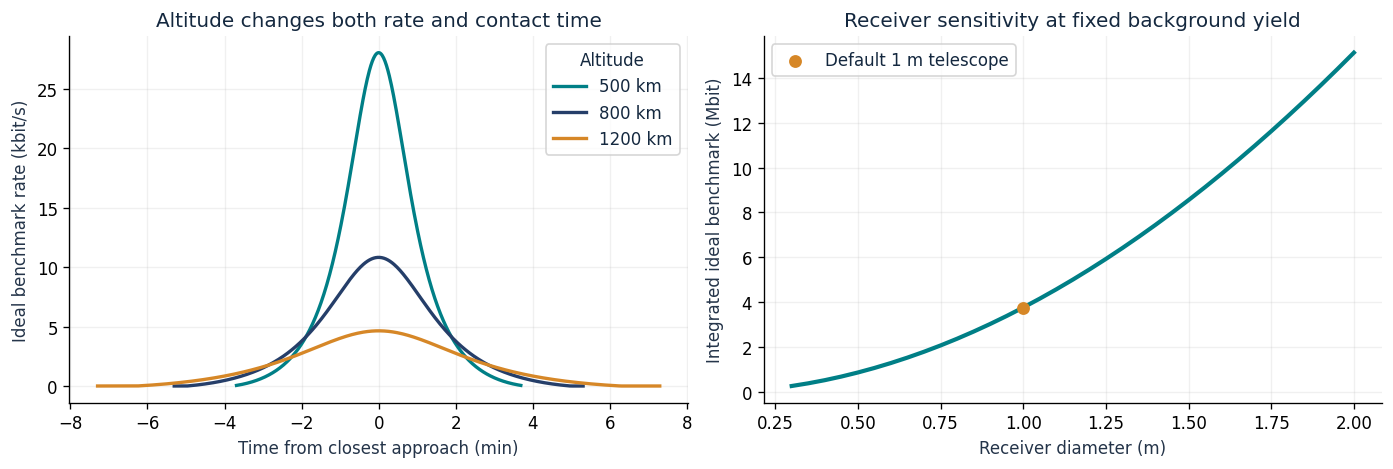

| Altitude (km) | Pass (s) | Peak (kbit/s) | Integrated benchmark (Mbit) |
| --- | --- | --- | --- |
| 500 | 442.64 | 28.022 | 3.7574 |
| 800 | 636.63 | 10.813 | 2.2800 |
| 1200 | 875.34 | 4.638 | 1.4315 |

In [7]:
altitudes = [500, 800, 1200]
altitude_passes = {height: simulate_pass(replace(p, altitude_km=height)) for height in altitudes}
diameters = np.linspace(0.3, 2.0, 35)
aperture_bits = [simulate_pass(replace(p, receiver_radius_m=d/2))["metrics"]["asymptotic_key_bits"]
                 for d in diameters]

fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.8), layout="constrained")
for height, result in altitude_passes.items():
    axes[0].plot(result["time_s"]/60, result["key_rate_bps"]/1000, label=f"{height} km", linewidth=2)
axes[0].set(xlabel="Time from closest approach (min)", ylabel="Ideal benchmark rate (kbit/s)",
            title="Altitude changes both rate and contact time")
axes[0].legend(title="Altitude")
axes[1].plot(diameters, np.array(aperture_bits)/1e6, linewidth=2.5)
axes[1].scatter([2*p.receiver_radius_m], [m["asymptotic_key_bits"]/1e6], s=45, color="#d68727",
                zorder=3, label="Default 1 m telescope")
axes[1].set(xlabel="Receiver diameter (m)", ylabel="Integrated ideal benchmark (Mbit)",
            title="Receiver sensitivity at fixed background yield")
axes[1].legend()
save_figure(fig, "leo_design_comparison")

table(["Altitude (km)", "Pass (s)", "Peak (kbit/s)", "Integrated benchmark (Mbit)"], [
    [height, f'{result["metrics"]["pass_duration_s"]:.2f}',
     f'{result["metrics"]["peak_key_rate_bps"]/1000:.3f}',
     f'{result["metrics"]["asymptotic_key_bits"]/1e6:.4f}']
    for height, result in altitude_passes.items()
])

## 8. Numerical checks that matter

The checks below verify physical limits and numerical integration: symmetry around zenith, exact geometry at closest approach, a background-only channel, an empty channel, and convergence when the pass grid is refined. They validate the implementation of this stated model; they do not validate the assumptions against a real satellite or establish protocol security.

In [8]:
np.testing.assert_allclose(baseline["elevation_deg"][[0, -1]], p.minimum_elevation_deg, atol=1e-9)
np.testing.assert_allclose(baseline["slant_range_km"], baseline["slant_range_km"][::-1], atol=1e-9)
np.testing.assert_allclose(baseline["key_rate_bps"], baseline["key_rate_bps"][::-1], rtol=1e-10)
zenith = link_at_elevation(90, p)
np.testing.assert_allclose(zenith["slant_range_km"], p.altitude_km, atol=1e-9)
np.testing.assert_allclose(zenith["atmosphere_path_km"], p.atmosphere_height_km, atol=1e-9)

background_only = link_at_elevation(60, replace(p, detector_efficiency=0))
assert background_only["qber"] == 0.5 and background_only["key_rate_bps"] == 0
empty_channel = link_at_elevation(60, replace(p, detector_efficiency=0, background_yield=0))
assert np.isnan(empty_channel["qber"]) and empty_channel["key_rate_bps"] == 0
assert binary_entropy(0) == 0 and binary_entropy(1) == 0 and binary_entropy(0.5) == 1

fine = simulate_pass(replace(p, sample_count=1601))
relative_difference = abs(m["asymptotic_key_bits"] - fine["metrics"]["asymptotic_key_bits"])/fine["metrics"]["asymptotic_key_bits"]
assert relative_difference < 1e-4
print("Passed: pass endpoints, symmetry, zenith, dark-only, empty channel, entropy and integration convergence.")
print(f"401 vs 1601 samples: integrated benchmark changes by {100*relative_difference:.6f}%.")

Passed: pass endpoints, symmetry, zenith, dark-only, empty channel, entropy and integration convergence.
401 vs 1601 samples: integrated benchmark changes by 0.000045%.


## 9. Interpretation and next experiments

For these inputs, closest approach improves the collected photon fraction and lowers the relative contribution of background clicks. The gain and ideal benchmark rate peak near zenith. Raising altitude increases contact duration and geometric loss; use the table above to compare their combined effect. Increasing aperture improves the benchmark when background is held fixed.

The extension excludes cloud outages, weather variability, turbulence/scintillation, adaptive optics, time-dependent pointing and tracking errors, Earth rotation, atmospheric refraction, non-overhead passes, detector saturation/dead time, daylight-dependent background, and real orbital scheduling. NASA describes pointing accuracy and weather as practical optical-communication constraints. [NASA, *Optical Communications*](https://www.nasa.gov/technology/space-comms/optical-communications-overview/).

The rate is also asymptotic: it has no decoy parameter-estimation bounds, finite-size penalties, authentication cost or composable failure probabilities. Pass-limited data can substantially change achievable key lengths, as studied by [Sidhu et al.](https://arxiv.org/abs/2012.07829). A trusted relay between two ground users would additionally require a second contact and an explicit trust/key-management design; this notebook models one downlink only.

**Useful next experiments:** change `altitude_km`, `minimum_elevation_deg`, `receiver_radius_m`, `divergence_rad`, `zenith_atmosphere_loss_db` or `background_yield` with `replace(p, ...)`, then rerun `simulate_pass`. Compare like-for-like inputs and label outputs as model benchmarks. The original terrestrial study remains available as the unchanged baseline.

## Files and reproducibility

| New file | Purpose |
|---|---|
| `QKD_FSO_LEO_Extension.ipynb` | This executed companion notebook |
| `QKD_FSO_LEO_Extension.html` | Browser-readable notebook export |
| `leo_model.py` | Independent NumPy implementation and fixture generator |
| `leo_python_reference.json` | Default pass metrics and 10°, 30°, 60°, 90° checkpoints for Octave comparison |
| `build_leo_notebook.py` | Rebuild and execute this notebook and HTML without editing the original stages |
| `test_leo_model.py` | Geometry, channel-limit and numerical-convergence checks |
| `python_figures/` | Four exported figure PNGs for project reports |

Rebuild from the project directory with `python "2-Ground Station and Satellite/build_leo_notebook.py"`.

## 10. DPS protocol statistics and atmospheric fading

This extension uses `shared/physics.py`, `shared/scenarios.py` and `shared/reporting.py`.
Earlier sections retain their historical deterministic models and finite BB84 demonstrations.
**DPS uses relative phases between coherent pulses, a one-pulse delay interferometer,
two threshold detectors and explicit valid-slot accounting.** It is not the earlier DPS teaching curve.

**DPS protocol QBER** is a detection statistic. **DPS illustrative rate proxy** uses a
collision-inspired privacy term from the restricted individual-attack analysis, combined
with the detector model described in `DPS_THEORY.md`. A DPS-specific composable secret-key
security bound has not been implemented or established. Its integral is an integrated
proxy, not certified secret-key material. The old BB84/Eve/LDPC/Toeplitz example is not DPS.

Fading is a normalized collected-power multiplier: `exp(sigma*X - sigma**2/2)`;
`sigma**2` is log-irradiance variance. Temporal correlation is phenomenological,
with `rho=exp(-dt/tau_c)` and stationary initialization. The detector factor is fixed;
optical clipping is reported. Ground links have independent random streams; vacuum
inter-satellite links do not receive atmospheric fading. No measured data are used.

Change the protocol and mode below, then restart and run all. Defaults here explicitly
select correlated fading for comparison; library defaults remain `none`.
Stage 3 retains trusted BB84/DPS and separate BBM92 operation. BBM92 always requires
simultaneous visibility and recalculates singles and accidental coincidences on both arms.
Hardware, source, clock resources and security assumptions differ across protocols.


Active protocol: DPS QKD
DPS parameters: {
  "mean_photons": 0.1,
  "visibility": 0.98,
  "phase_error_rad": 0.0,
  "background_per_detector": 1e-06,
  "ec_efficiency": 1.16,
  "pulse_rate_hz": 100000000.0,
  "duty": 0.8,
  "train_pulses": 1024,
  "guard_slots": 1
}
Fading parameters: {
  "mode": "correlated_lognormal",
  "sigma": 0.3,
  "correlation_time_s": 2.0,
  "seed": 123
}
DPS illustrative rate proxy; no composable security bound established


| Quantity (units in field name) | Value |
|---|---|
| mean_qber | 0.04725325721885275 |
| median_qber | 0.027035340888409816 |
| p95_qber | 0.14887713196537974 |
| mean_rate_bps | 4070.455597783806 |
| median_rate_bps | 1342.0186255356462 |
| p05_rate_bps | 0.0 |
| outage_fraction | 0.3192019950124688 |
| pooled_qber | 0.018693817518486856 |
| integrated_rate_bits | 1806234.3036383614 |
| time_outage_fraction | 0.3175 |
| rate_at_mean_efficiency_bps | 3799.778354580093 |
| rate_at_mean_efficiency_scope | single continuously open gate at mean eta; includes unavailable samples in mean eta |

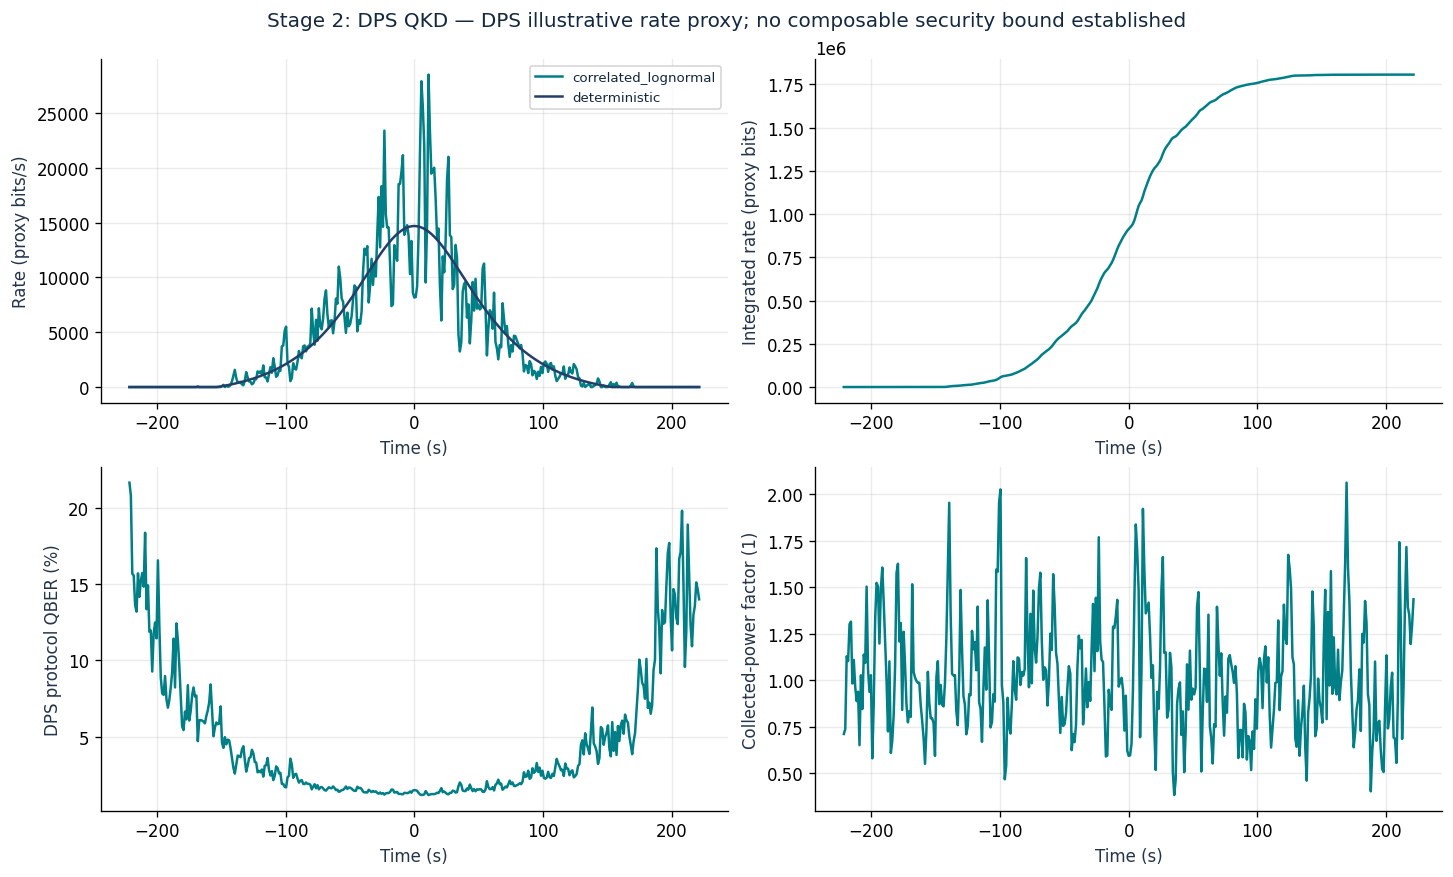

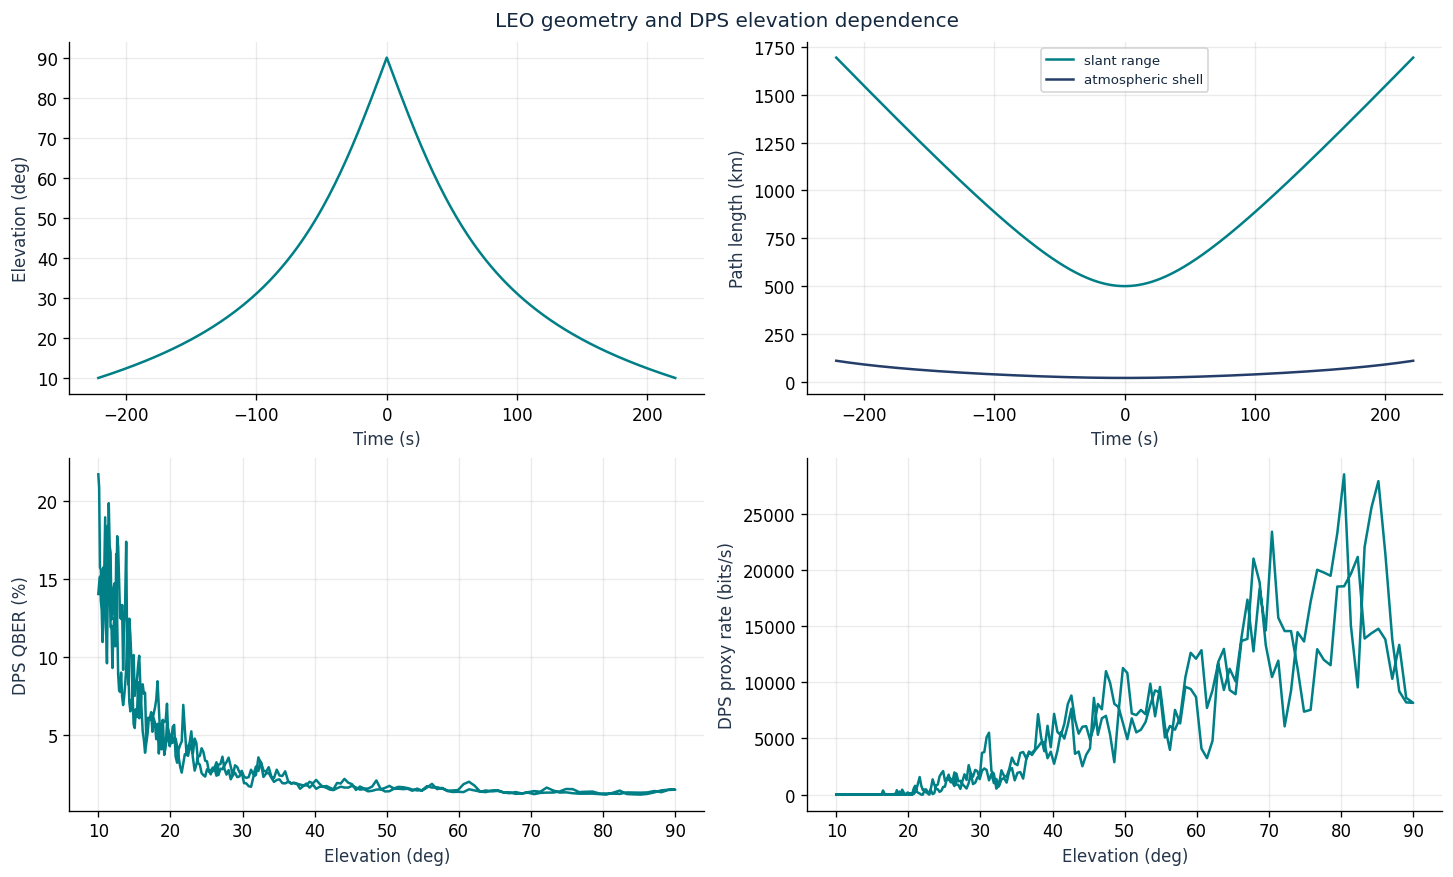

Exports: d:\IIT Class\Project\Submission\2-Ground Station and Satellite\dps_turbulence_notebook_results


In [9]:
from pathlib import Path
import sys, json
from dataclasses import asdict
from IPython.display import display, Markdown, Image
project_root = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "shared" / "physics.py").is_file())
if str(project_root) not in sys.path: sys.path.insert(0, str(project_root))
from shared.physics import DPSParameters, FadingParameters
from shared.scenarios import run_stage
from shared.reporting import export_result, plot_result, study
import matplotlib.pyplot as plt

active_protocol = "DPS QKD"  # Stage 1: BB84, Decoy-state BB84, DPS QKD; others: latter two
architecture = "trusted"    # Stage 3 only: trusted or bbm92
dps_settings = DPSParameters()
fading_settings = FadingParameters(mode="correlated_lognormal", sigma=0.3, correlation_time_s=2.0, seed=123)
extra = {"mode": architecture} if 2 == 3 else {}
extension_result = run_stage(2, protocol=active_protocol, fading=fading_settings, dps=dps_settings, **extra)
extension_baseline = run_stage(2, protocol=active_protocol, dps=dps_settings, **extra)
print("Active protocol:", extension_result["metadata"]["protocol"])
print("DPS parameters:", json.dumps(asdict(dps_settings), indent=2))
print("Fading parameters:", json.dumps(asdict(fading_settings), indent=2))
print(extension_result["metadata"]["security_status"])
summary_rows = "\n".join(f"| {k} | {v} |" for k,v in extension_result["summary"].items())
display(Markdown("| Quantity (units in field name) | Value |\n|---|---|\n" + summary_rows))
extension_figures = plot_result(extension_result, extension_baseline)
plt.show()
for extension_figure in extension_figures: plt.close(extension_figure)
extension_folder = project_root / '2-Ground Station and Satellite' / "dps_turbulence_notebook_results"
export_result(extension_result, extension_folder)
print("Exports:", extension_folder)


### Interpretation, ensemble study and exports

Mean instantaneous QBER excludes undefined zero-detection samples. Pooled QBER is total
expected errors divided by total expected detections. They generally differ. Sample outage
and time-weighted outage are both exported. Mean instantaneous rate and the rate at mean
efficiency also differ; the latter is a hypothetical continuously open link, not a pass average.
For unavailable satellite contacts, the detection gates are closed and rates are zero.

The following reproducible **default DPS design study** is separate from the selected run above.
It uses fixed geometry and 12 independent seeds, plus five seeds at each turbulence strength.
The plotted sample intervals are descriptive, not confidence bounds or proof of a general trend.
Monte Carlo histograms have sample-count axes, not seconds. All zero rates remain zero.
Reports contain parameters, assumptions, units, seeds, CSV arrays and JSON metadata.


| Seed | Integrated DPS proxy (bits) | Outage sample fraction |
|---|---|---|
| 1000 | 1.81696e+06 | 0.2943 |
| 1001 | 1.69527e+06 | 0.2993 |
| 1002 | 1.67534e+06 | 0.3441 |
| 1003 | 1.68143e+06 | 0.3042 |
| 1004 | 1.72412e+06 | 0.3042 |
| 1005 | 1.71651e+06 | 0.3242 |
| 1006 | 1.67972e+06 | 0.3067 |
| 1007 | 1.77933e+06 | 0.3092 |
| 1008 | 1.60719e+06 | 0.3441 |
| 1009 | 1.64481e+06 | 0.3367 |
| 1010 | 1.80802e+06 | 0.2918 |
| 1011 | 1.56204e+06 | 0.3217 |

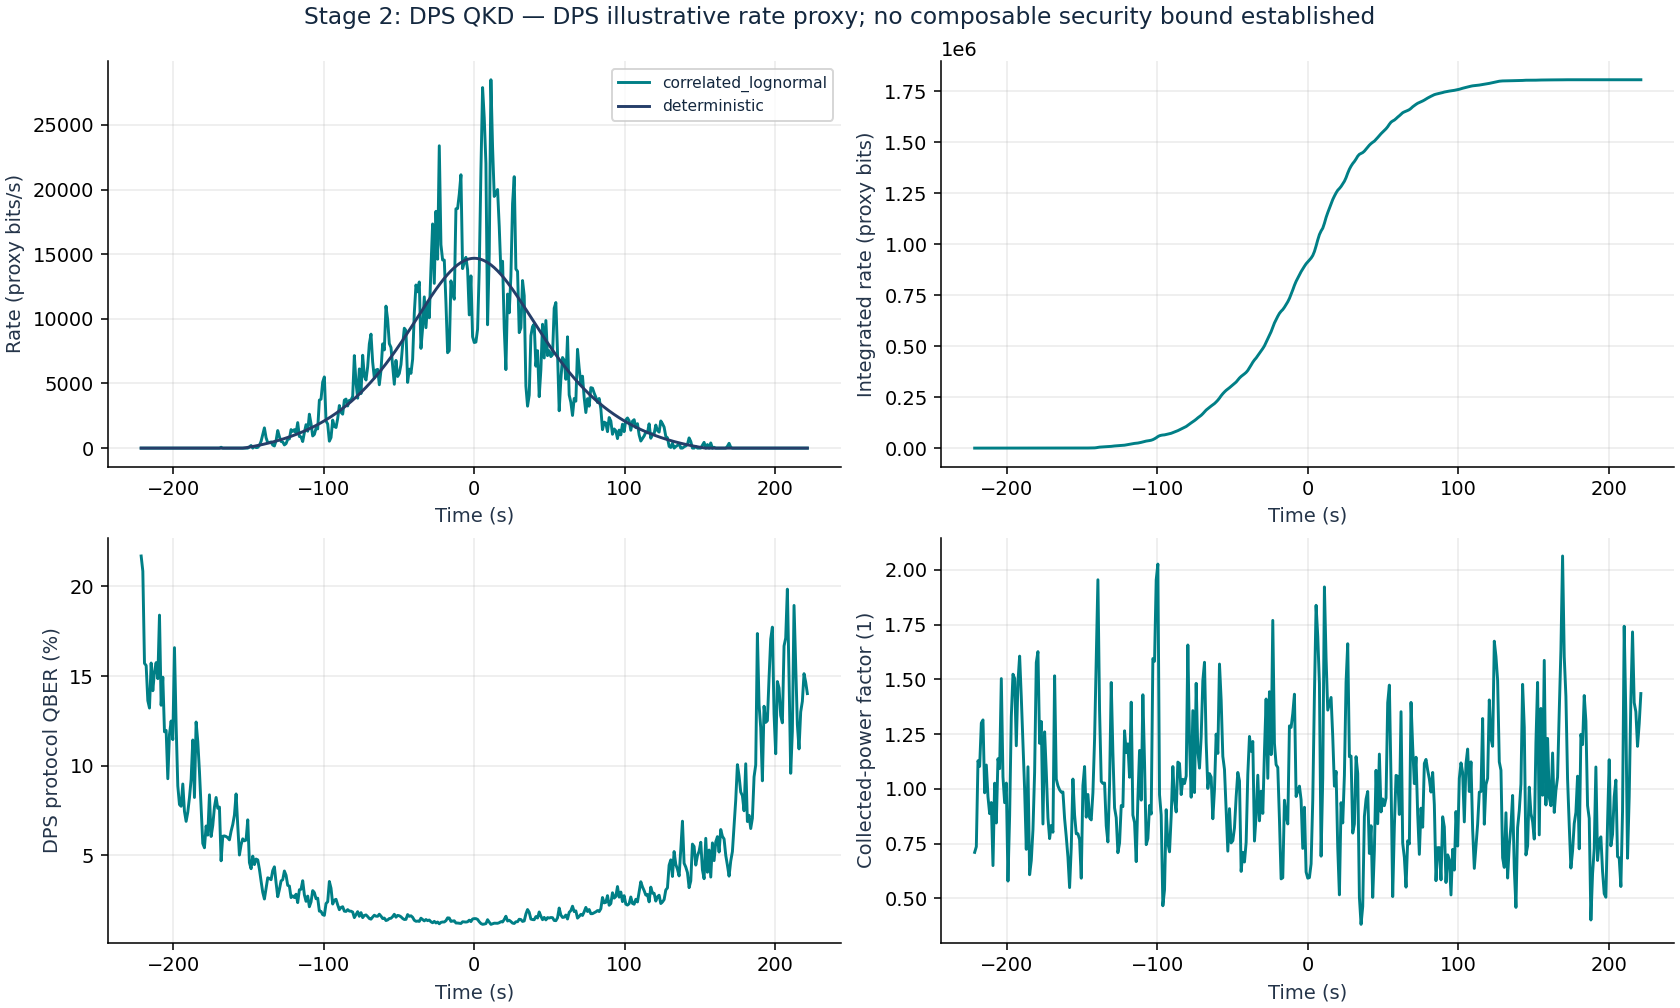

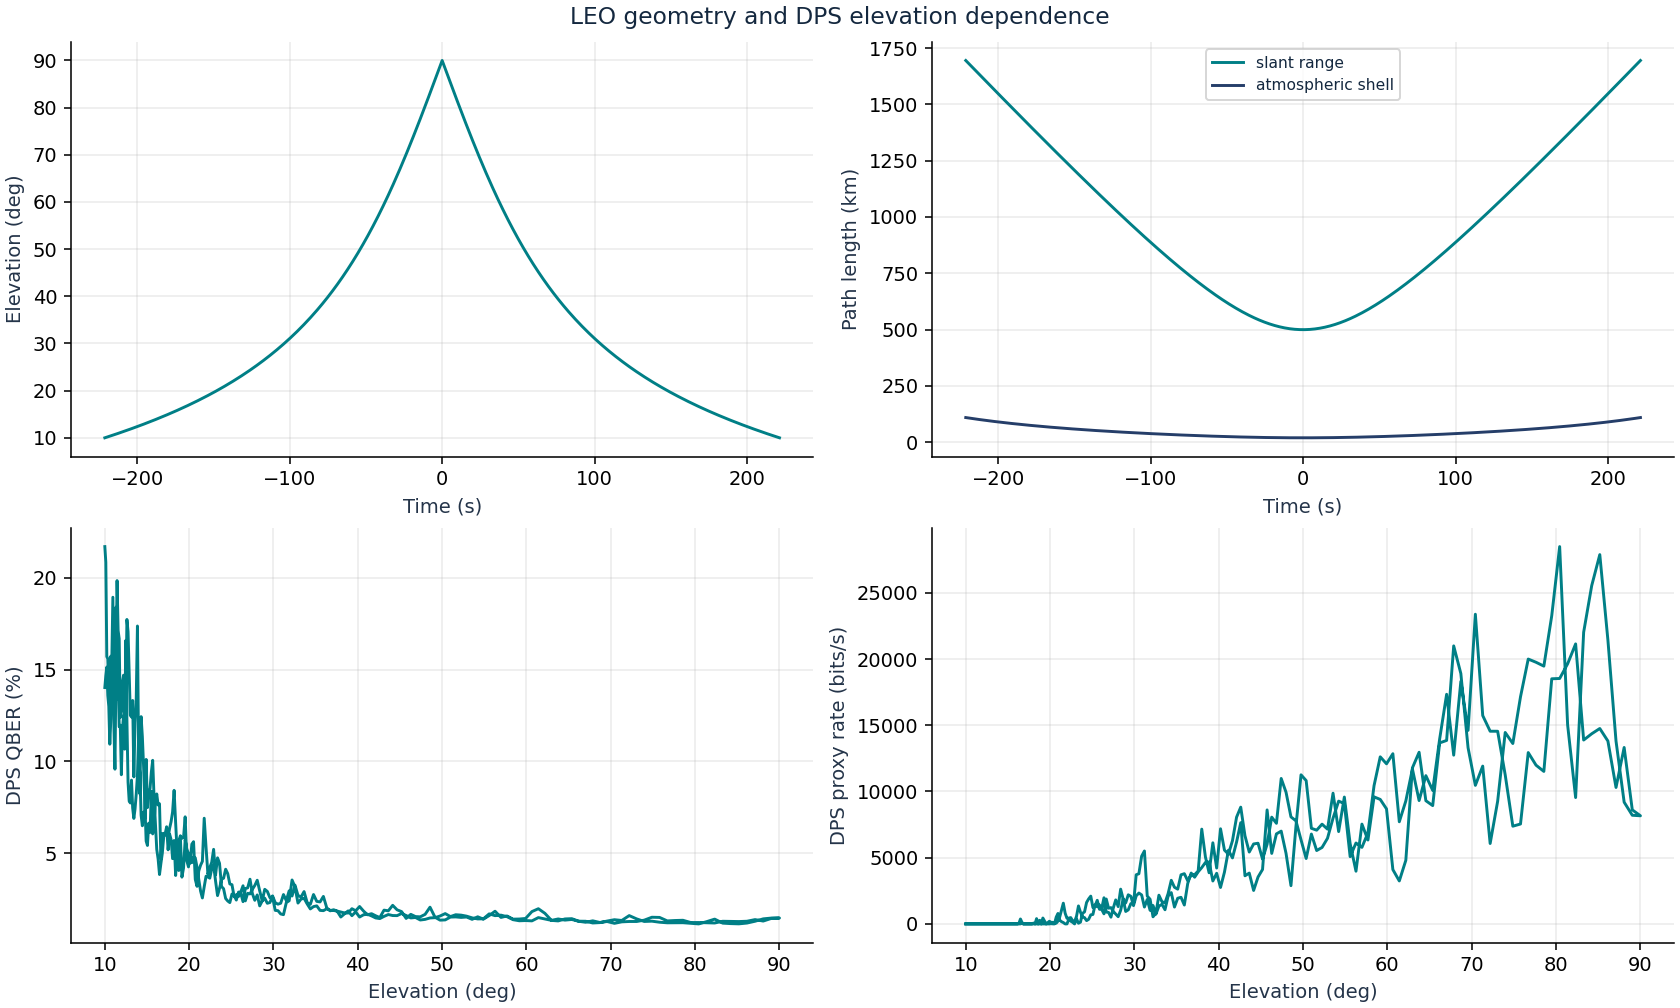

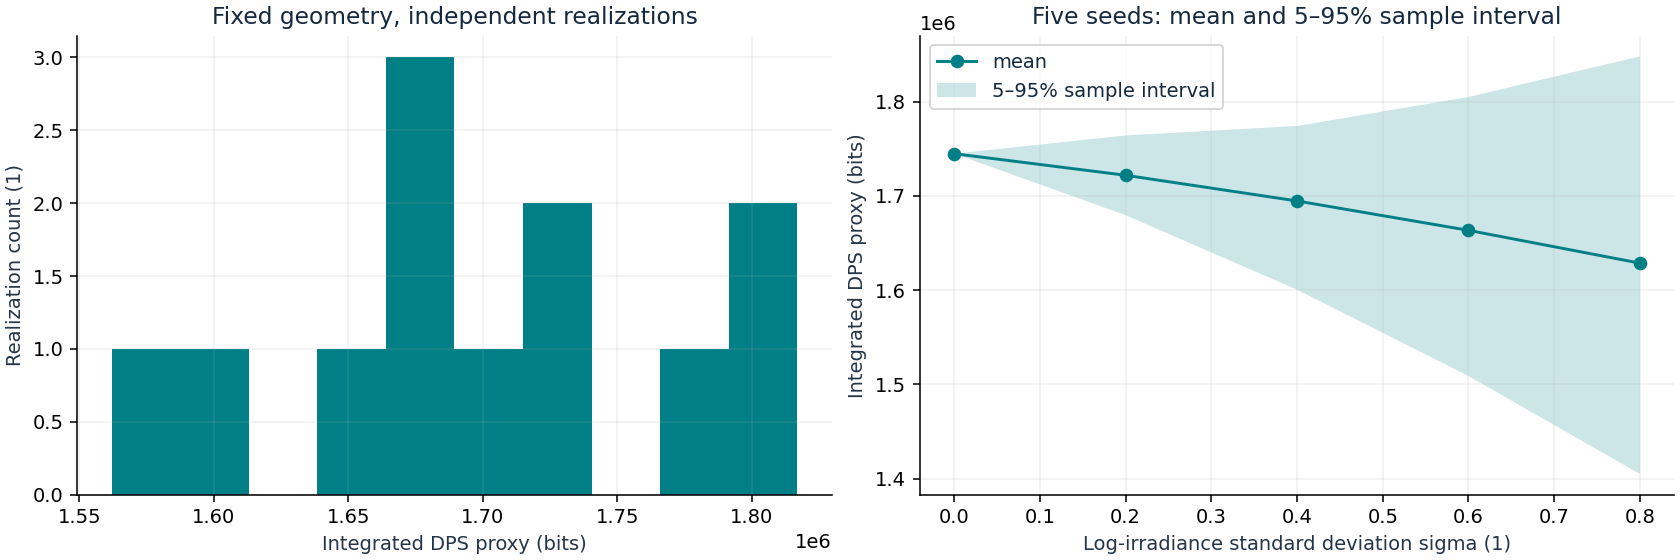

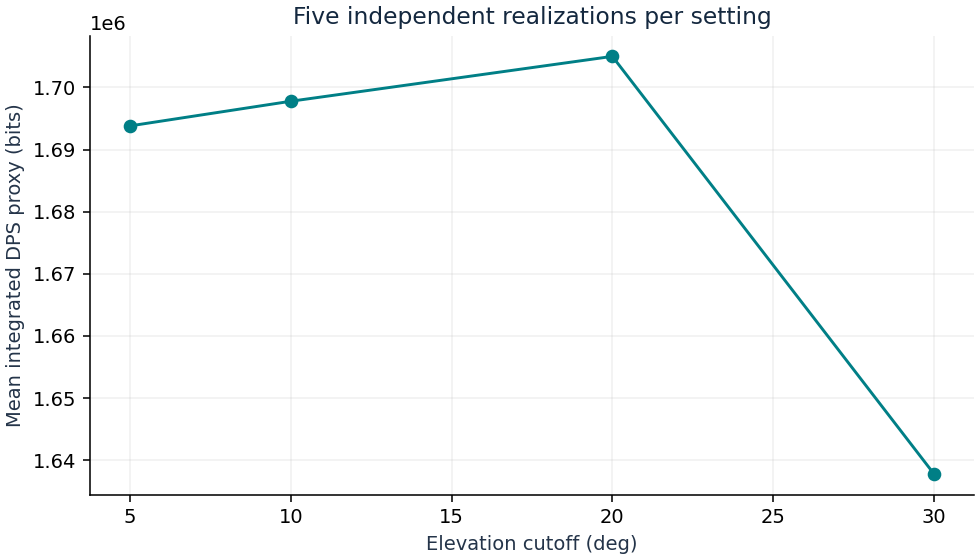

Default study HTML: d:\IIT Class\Project\Submission\2-Ground Station and Satellite\dps_turbulence_results\report.html


In [10]:
default_study_folder = project_root / '2-Ground Station and Satellite' / "dps_turbulence_results"
default_study_result, realization_rows, sensitivity_rows = study(2, default_study_folder)
display(Markdown("| Seed | Integrated DPS proxy (bits) | Outage sample fraction |\n|---|---|---|\n" +
    "\n".join(f"| {row['seed']} | {row['integrated_rate_bits']:.6g} | {row['outage_fraction']:.4f} |" for row in realization_rows)))
for image_path in sorted(default_study_folder.glob("figure_*.png")):
    display(Image(filename=str(image_path)))
print("Default study HTML:", default_study_folder / "report.html")
